# Numerical vs. Neurical Solutions for a Single-Phase Problem

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://drive.google.com/file/d/1X3UQadRKmtdI7MK6hP1HsHY2DJvO41g8/view?usp=drive_link&target=_blank)

*Author: Zakariya Abugrin | Date: May 2025*

In [1]:
# Colab only:
try:
    # Install reservoirflow in Colab
    import os
    import google.colab
    !pip install -q reservoirflow
    # Restart session after installation
    os.kill(os.getpid(), 9)
    print("Session was restarted.")
    print("Now you can run to the following cells.")
except ImportError:
    pass

## Introduction

Numerical solutions fully based on physics requires extensive domain knowledge to develop. Moreover, simulation runs based on these models remain computationally expensive, limiting the ability to take real-time decisions. Alternatively, AI proxy models trained on simulation data are used to capture the physics implicitly to be used for fast prediction. However, these models remain dependent on reservoir simulation data and can't be extended beyond the training data. 

## Prerequisites:
Before you can follow this tutorial, you need to understand the following tutorials:
1. [Understand Compiling](/user_guide/tutorials/tutorial_understand_compiling.html).
2. [Different Solutions for 1-Dimensional-1-Phase Problem](/user_guide/tutorials/tutorial_different_solutions_1D1P.html).

<!-- ![image](grid_animated.gif) -->
![image](https://drive.google.com/thumbnail?id=1M4DAZ_AjIVYES2WEEaFMY34Gm3-iDRf9&sz=w1000)\
**the code used to generate this gif image is shown in [Save simulation run as gif](#save-simulation-run-as-gif) section below.*

## Import `reservoirflow`

We start with importing `reservoirflow` as `rf`. The abbreviation `rf` refers to `reservoirflow` where all modules under this library can be accessed. `rf` is also used throughout the [API](/api/API.html) documentation. We recommend our users to stick with this convention.

In [2]:
import reservoirflow as rf
import numpy as np

print(rf.__version__)

0.1.0b3


In [3]:
static = notebook = True

- Both `static` and `notebook` are set to `True` to produce images for this notebook. For an interactive visualization in your local machine, set both arguments to `False`. To allow for interactive visualizations in Colab, set only `static=False` and keep `notebook=True`. 

In [4]:
rf.utils.pyvista.set_mode("dark")

- By default, `"dark"` mode is used with a black background. You can change to `"light"` mode using `rf.utils.pyvista.set_mode()` function. 

In [5]:
g_comp = 1e-6
f_comp = 1e-5
nx=50
ny=50
ny=3
dx=300
dy=350
dz=40
phi=0.27
kx=270
ky =270
kz = 50
nsteps=100
n_w=2 
dtype="double" 
verbose=False
boundary=False
scalers = {
        "time": ("MinMax", (0, 1)),
        "space": ("MinMax", (0, 1)),
        "pressure": ("MinMax", (0, 1)),
    }

## 1D Model

We start with a 1D model

# Grid
nx = 100
grid = rf.grids.RegularCartesian(
    nx=100,
    ny=1,
    nz=1,
    dx=300,
    dy=350,
    dz=40,
    phi=0.27,
    kx=270,
    comp=g_comp,
    dtype=dtype,
)
# Fluid
fluid = rf.fluids.SinglePhase(
    mu=0.5,
    B=1,
    comp=f_comp,
    dtype=dtype,
)
# Model
model = rf.models.BlackOil(
    grid, 
    fluid, 
    pi=4000, 
    dtype=dtype, 
    dt=1, 
    verbose=verbose,
    )
# Boundaries
model.set_boundaries(
    {
        0: ("pressure", 1000),  # left boundary
        nx + 1: ("pressure", 4000),  # right boundary
    }
)
# Scalers
model.set_scalers(scalers)

# Show grid
static = notebook = True
grid.show(
    title="1D Grid",
    label="id",
    boundary=boundary,
    static=static,
    notebook=notebook,
    azimuth=-90,
    elevation=10,
    zoom=1.7,
)

# Numerical solution
model.compile(
    stype="numerical",  
    method="FDM",
    sparse=True,
    name=f"FDM",
)
model.run(
    nsteps=nsteps,
    threading=True,
    vectorize=True,
)

# Neurical solution
model.compile(
    stype="neurical",
    method="PINN",
    sparse=True,
    name=f"PINN",
)
model.run(
    nsteps=nsteps, 
    threading=True, 
    vectorize=True, 
    reference="FDM",
)

model.plot(solution="all", scale=True)

## 2D Model

In [6]:
# Grid
n = 10
grid = rf.grids.RegularCartesian(
    nx=n,
    ny=n,
    nz=1,
    dx=300,
    dy=300,
    dz=40,
    phi=0.27,
    kx=10,
    ky=10,
    comp=g_comp,
    dtype=dtype,
)
# Fluid
fluid = rf.fluids.SinglePhase(
    mu=0.5,
    B=1,
    comp=f_comp,
    dtype=dtype,
)
# Model
model = rf.models.BlackOil(
    grid,
    fluid,
    pi=4000,
    dtype=dtype,
    dt=1,
    verbose=verbose,
)
# Boundaries
south_boundaries = np.arange(1, 11)
north_boundaries = np.arange(133, 143)
model.set_boundaries(
    {i: ("pressure", 1000) for i in south_boundaries}
    | {i: ("pressure", 4000) for i in north_boundaries}
)
# Scalers
model.set_scalers(scalers)

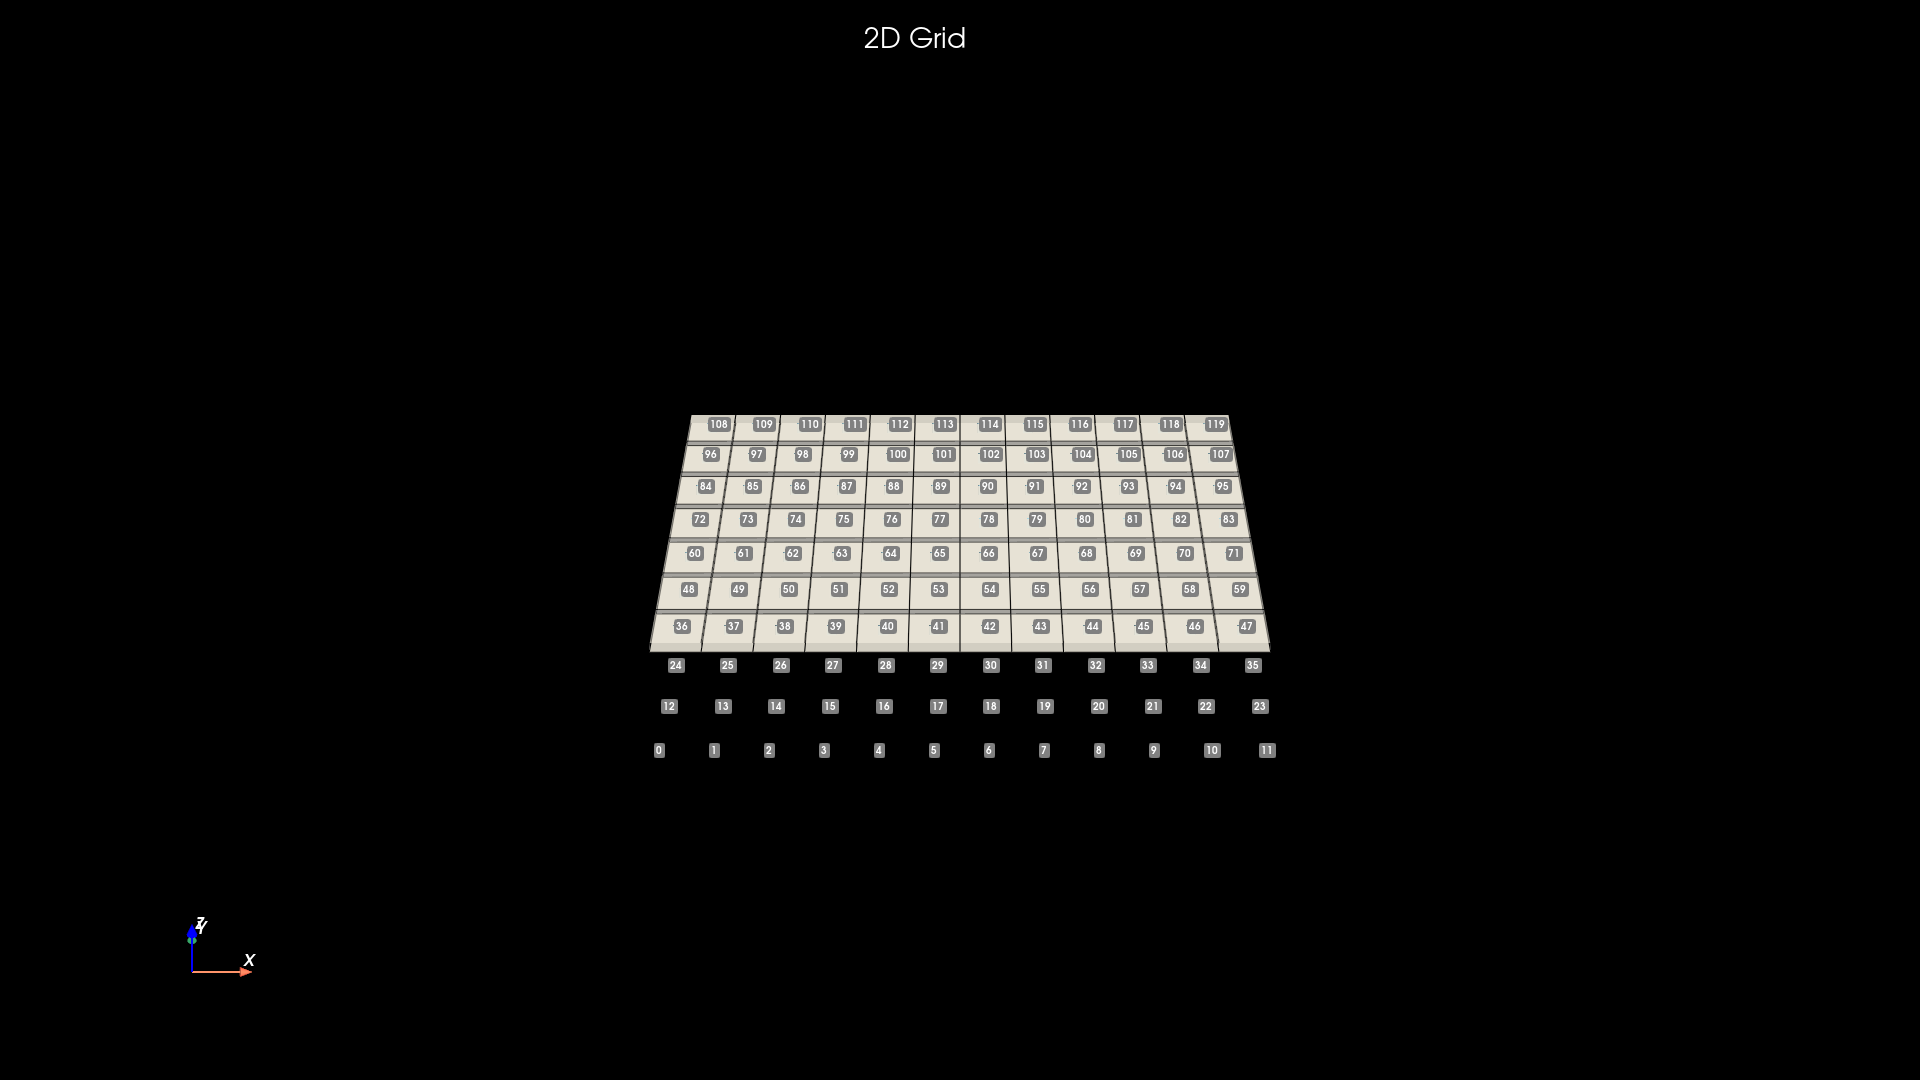

In [7]:
static = notebook = True
boundary = True
grid.show(
    title="2D Grid",
    label="id",
    boundary=boundary,
    static=static,
    notebook=notebook,
    azimuth=0,
    elevation=-45,
    zoom=0.8,
)

In [8]:
# Numerical solution
model.compile(
    stype="numerical",
    method="FDM",
    sparse=True,
    name=f"FDM",
)
model.run(
    nsteps=nsteps,
    threading=True,
    vectorize=True,
)


[info] FDM was assigned as model.solution.
[info] Simulation run started: 100 timesteps.


[step]: 100%|██████████| 100/100 [00:00<00:00, 168.39steps/s]

[info] Simulation run of 100 steps finished in 0.6 seconds.
[info] Material Balance Error: 1.1213252548714081e-13.


In [9]:
model.get_factors(
    boundary=True,
    scale=True,
    method='mean',
)[0]

S_px: [0.00027548 0.00027548] S_pt: 30.0 S_q: 1


array([6.20936639e-06, 6.20936639e-06])

In [10]:
# Neurical solution
model.compile(
    stype="neurical",
    method="PINN",
    sparse=True,
    name=f"PINN",
)
model.run(
    nsteps=nsteps,
    threading=True,
    vectorize=True,
    reference="FDM",
)

Using GPU: NVIDIA RTX 5000 Ada Generation Laptop GPU
[info] PINN was assigned as model.solution.
[info] Simulation run started: 100 timesteps.
[info] pressures array shape was updated. This happens due to increasing nsteps manually or due to solutions in multiple nsteps.
[info] rates array shape was updated. This happens due to increasing nsteps manually or due to solutions in multiple nsteps.
[info] length of full domain: 14544
[info] length of data domain: 2120
[info] length of test domain: 14544
[info] length of physics domain: 14400


  0%|          | 0/150 [00:00<?, ?epochs/s]c:\Users\abugrzka\Projects\hiesab\reservoirflow\.venv\Lib\site-packages\torch\autograd\graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
[epoch] 150 - [loss total] 0.008327 - [loss test] 0.006367 - [loss data] 0.008975 - [loss residual] 0.003927: 100%|██████████| 150/150 [00:04<00:00, 32.65epochs/s]


[info] Pinn fitting of 150 epochs finished in 0.077 minutes -  loss (test): 0.006367.


[epoch] 150 - [loss total] 0.002487 - [loss test] 0.002841 - [loss data] 0.002559 - [loss residual] 0.001996: 100%|██████████| 150/150 [00:16<00:00,  9.09epochs/s]

[info] Pinn fitting of 150 epochs finished in 0.275 minutes -  loss (test): 0.002841.
[info] Simulation run of 100 steps finished in 22.33 seconds.
[info] Material Balance Error: 0.6338522815790637.


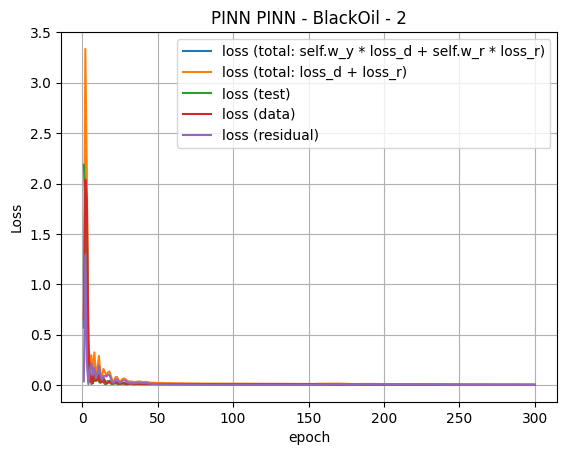

,run_id,epoch,loss (total),loss (test),loss (data),loss (residual),loss_d + loss_r,time
0,1,1,0.57175267,2.1861098,0.6503813,0.037670933,0.688052,0.41
1,1,2,1.9435833,1.8509928,2.038791,1.2968894,3.335680,0.08
2,1,3,1.6350497,0.41313615,1.841189,0.23485726,2.076046,0.07
3,1,4,0.39133894,0.032354154,0.44752678,0.009685498,0.457212,0.09
4,1,5,0.048024535,0.09672569,0.03289853,0.15076722,0.183666,0.08
...,...,...,...,...,...,...,...,...
295,2,296,0.0025130343,0.0029754795,0.0025986645,0.0019313946,0.004530,0.09
296,2,297,0.0025057662,0.0030267416,0.002585059,0.0019671733,0.004552,0.08
297,2,298,0.0024967908,0.0028918844,0.002568605,0.0020089974,0.004578,0.08
298,2,299,0.0024941966,0.0028879133,0.0025653902,0.0020106167,0.004576,0.09


In [11]:
model.solution.plot()

In [12]:
static = notebook = False
boundary = False
model.solution.update_pressures()
model.set_solution("PINN")
model.show(
    prop="pressures",
    boundary=True,
    cmap="Blues",
    static=static,
    notebook=notebook,
)

```{include} /_static/comments_section.md
```